## EDA для `python_1/data/tested.xls`

Этот ноутбук:
- читает файл `python_1/data/tested.xls` (фактически это CSV, несмотря на расширение);
- делает разведывательный анализ данных по столбцам;
- строит базовые графики и сводные таблицы.

> Если окружение «голое», потребуется `pandas`, `numpy`, `matplotlib`, `seaborn`.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

DATA_PATH = Path("/home/owltower/Projects/tutor/python_1/data/tested.xls")
DATA_PATH


ModuleNotFoundError: No module named 'seaborn'

In [ ]:
def read_table_smart(path: Path) -> pd.DataFrame:
    """Пытаемся прочитать как Excel; если не получается — читаем как CSV.

    В этом проекте файл `tested.xls` на самом деле CSV (запятая, UTF-8).
    """
    # 1) Попытка Excel (на случай, если в будущем положат настоящий .xls/.xlsx)
    try:
        return pd.read_excel(path)
    except Exception:
        pass

    # 2) CSV fallback
    # pandas умеет авто-определять разделитель через engine='python' + sep=None
    # (чуть медленнее, но удобно для «непонятных» файлов)
    try:
        return pd.read_csv(path, sep=None, engine="python")
    except UnicodeDecodeError:
        # На случай экзотических кодировок
        return pd.read_csv(path, sep=None, engine="python", encoding="utf-8", errors="replace")


df = read_table_smart(DATA_PATH)
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
# Базовая информация
print("shape:", df.shape)
df.info()

# Дубликаты строк
n_dups = df.duplicated().sum()
print("duplicates:", int(n_dups))

# Быстрый взгляд на несколько строк
(df.sample(min(5, len(df)), random_state=42) if len(df) else df).reset_index(drop=True)


shape: (418, 12)
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB
duplicates: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1213,0,3,"Krekorian, Mr. Neshan",male,25.0,0,0,2654,7.2292,F E57,C
1,1216,1,1,"Kreuchen, Miss. Emilie",female,39.0,0,0,24160,211.3375,NaN,S
2,1280,0,3,"Canavan, Mr. Patrick",male,21.0,0,0,364858,7.7500,NaN,Q
3,948,0,3,"Cor, Mr. Bartol",male,35.0,0,0,349230,7.8958,NaN,S
4,1045,1,3,"Klasen, Mrs. (Hulda Kristina Eugenia Lofqvist)",female,36.0,0,2,350405,12.1833,NaN,S


In [ ]:
print(df)

    PassengerId Survived Pclass                                          Name  \
0           892        0      3                              Kelly, Mr. James   
1           893        1      3              Wilkes, Mrs. James (Ellen Needs)   
2           894        0      2                     Myles, Mr. Thomas Francis   
3           895        0      3                              Wirz, Mr. Albert   
4           896        1      3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)   
..          ...      ...    ...                                           ...   
413        1305        0      3                            Spector, Mr. Woolf   
414        1306        1      1                  Oliva y Ocana, Dona. Fermina   
415        1307        0      3                  Saether, Mr. Simon Sivertsen   
416        1308        0      3                           Ware, Mr. Frederick   
417        1309        0      3                      Peter, Master. Michael J   

        Sex   Age SibSp  Pa

In [ ]:
# Статистика пропусков по столбцам
missing = (
    df.isna()
      .sum()
      .to_frame("n_missing")
      .assign(pct_missing=lambda x: x["n_missing"] / len(df) * 100 if len(df) else 0)
      .sort_values(["n_missing"], ascending=False)
)
missing


,n_missing,pct_missing
Cabin,327,78.229665
Age,86,20.574163
Fare,1,0.239234
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000


In [ ]:
# Уникальные значения / кардинальность
cardinality = (
    df.nunique(dropna=True)
      .to_frame("n_unique")
      .assign(pct_unique=lambda x: x["n_unique"] / len(df) * 100 if len(df) else 0)
      .sort_values(["n_unique"], ascending=False)
)
cardinality


,n_unique,pct_unique
PassengerId,418,100.000000
Name,418,100.000000
Ticket,363,86.842105
Fare,169,40.430622
Age,79,18.899522
Cabin,76,18.181818
Parch,8,1.913876
SibSp,7,1.674641
Embarked,3,0.717703
Pclass,3,0.717703


In [ ]:
# Разделим признаки по типам + учтём доменную специфику Titanic
# Важно: некоторые "числа" — это на самом деле категории.

TARGET_COL = "Survived" if "Survived" in df.columns else None
ID_COLS = ["PassengerId"] if "PassengerId" in df.columns else []

# Пользовательская оговорка: трактуем как категориальные (даже если dtype числовой)
FORCED_CATEGORICAL = [c for c in ["PassengerId", "Survived", "Pclass", "SibSp"] if c in df.columns]

# Приведём к category для корректного EDA
for c in FORCED_CATEGORICAL:
    df[c] = df[c].astype("Int64").astype("category") if pd.api.types.is_numeric_dtype(df[c]) else df[c].astype("category")

# Базовое разбиение
cat_cols = sorted(set(df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()))
num_cols = [c for c in df.select_dtypes(include=["number"]).columns.tolist() if c not in cat_cols]
other_cols = [c for c in df.columns if c not in num_cols + cat_cols]

# Для ML/классификации удобно отделять фичи от таргета/ID
feature_cols = [c for c in df.columns if c not in (ID_COLS + ([TARGET_COL] if TARGET_COL else []))]

print("TARGET_COL:", TARGET_COL)
print("ID_COLS:", ID_COLS)
print("n_features:", len(feature_cols))

num_cols, cat_cols, other_cols


TARGET_COL: Survived
ID_COLS: ['PassengerId']
n_features: 10


/tmp/ipykernel_9372/3114022840.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = sorted(set(df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()))


(['Age', 'Parch', 'Fare'],
 ['Cabin',
  'Embarked',
  'Name',
  'PassengerId',
  'Pclass',
  'Sex',
  'SibSp',
  'Survived',
  'Ticket'],
 [])

In [ ]:
# Классификация: базовый взгляд на таргет
if TARGET_COL is None:
    print("В датасете нет столбца Survived — тогда это тестовая выборка Kaggle Titanic (без таргета).")
else:
    y = df[TARGET_COL].astype("string")
    display(y.value_counts(dropna=False).to_frame("count").assign(share=lambda x: x["count"] / len(df)))

    # baseline: всегда предсказывать самый частый класс
    majority = y.value_counts(dropna=False).idxmax()
    baseline_acc = (y == majority).mean()
    print(f"majority class: {majority}; baseline accuracy: {baseline_acc:.3f}")


,count,share
Survived,,
0,266,0.636364
1,152,0.363636


majority class: 0; baseline accuracy: 0.636


In [ ]:
plot_df = df[["Sex", "Pclass", TARGET_COL]].dropna().copy()
plot_df["_y"] = plot_df[TARGET_COL].astype("Int64")
print(plot_df)
plt.figure(figsize=(7, 4))
sns.barplot(data=plot_df, x="Pclass", y="", hue="Sex", estimator=np.mean, errorbar=None)
plt.ylabel("P(Survived=1)")
plt.title("Survival rate by Pclass and Sex")
plt.tight_layout()
plt.show()

        Sex Pclass Survived  _y
0      male      3        0   0
1    female      3        1   1
2      male      2        0   0
3      male      3        0   0
4    female      3        1   1
..      ...    ...      ...  ..
413    male      3        0   0
414  female      1        1   1
415    male      3        0   0
416    male      3        0   0
417    male      3        0   0

[418 rows x 4 columns]


ValueError: Could not interpret value `` for `y`. An entry with this name does not appear in `data`.

<Figure size 700x400 with 0 Axes>


--- Survived rate by Sex ---


,survival_rate,n
Sex,,
male,0.0,266
female,1.0,152



--- Survived rate by Pclass ---


,survival_rate,n
Pclass,,
3,0.330275,218
1,0.46729,107
2,0.322581,93



--- Survived rate by Embarked ---


,survival_rate,n
Embarked,,
S,0.325926,270
C,0.392157,102
Q,0.521739,46



--- Survived rate by SibSp ---


,survival_rate,n
SibSp,,
0,0.310954,283
1,0.490909,110
2,0.428571,14
3,0.25,4
4,0.25,4
8,0.5,2
5,1.0,1



--- Survived rate by Parch ---


,survival_rate,n
Parch,,
0,0.305556,324
1,0.538462,52
2,0.606061,33
3,0.666667,3
4,1.0,2
9,0.5,2
5,0.0,1
6,0.0,1


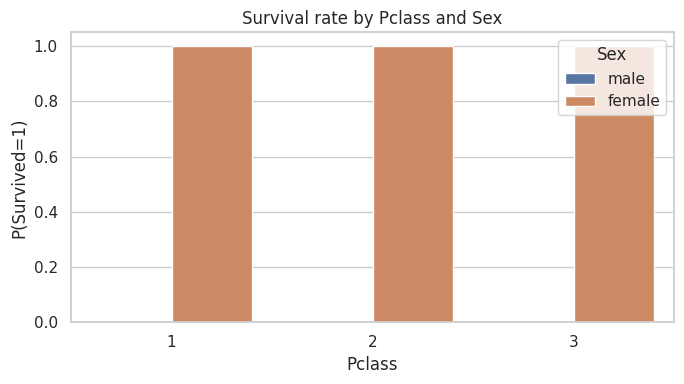

In [ ]:
# Классификация: влияние категориальных признаков на Survived
if TARGET_COL is not None:
    # Покажем rate (P(Survived=1)) по нескольким ключевым категориям
    key_cats = [c for c in ["Sex", "Pclass", "Embarked", "SibSp", "Parch"] if c in df.columns]

    for c in key_cats:
        tmp = (
            df[[c, TARGET_COL]]
            .dropna()
            .assign(_y=lambda x: x[TARGET_COL].astype("Int64"))
            .groupby(c, dropna=False, observed=True)["_y"].agg(["mean", "count"]).sort_values("count", ascending=False)
            .rename(columns={"mean": "survival_rate", "count": "n"})
        )
        print(f"\n--- Survived rate by {c} ---")
        display(tmp)

    # Визуально: survival rate по Sex и Pclass (если есть)
    if all(c in df.columns for c in ["Sex", "Pclass"]):
        plot_df = df[["Sex", "Pclass", TARGET_COL]].dropna().copy()
        plot_df["_y"] = plot_df[TARGET_COL].astype("Int64")
        plt.figure(figsize=(7, 4))
        sns.barplot(data=plot_df, x="Pclass", y="_y", hue="Sex", estimator=np.mean, errorbar=None)
        plt.ylabel("P(Survived=1)")
        plt.title("Survival rate by Pclass and Sex")
        plt.tight_layout()
        plt.show()


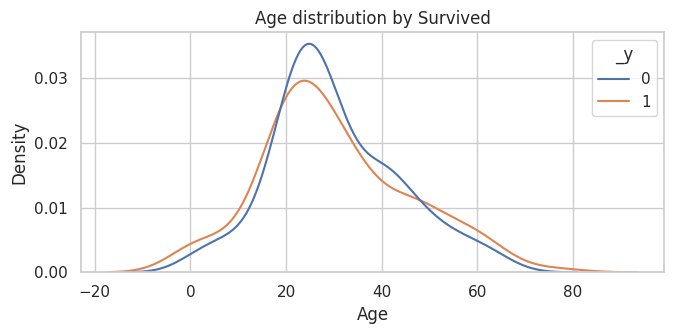

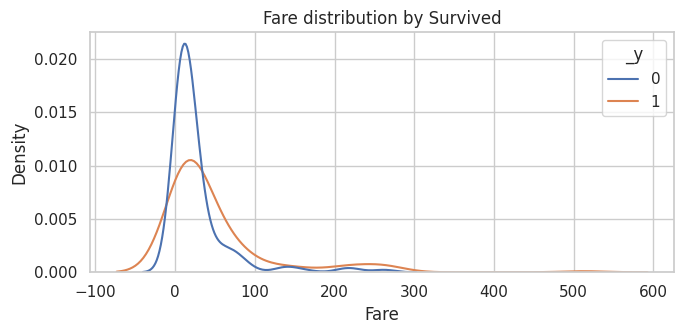

,survival_rate,n
age_bin,,
"[0, 12)",0.434783,23
"[12, 18)",0.388889,18
"[18, 30)",0.375,144
"[30, 45)",0.313953,86
"[45, 60)",0.468085,47
"[60, 80)",0.5,14


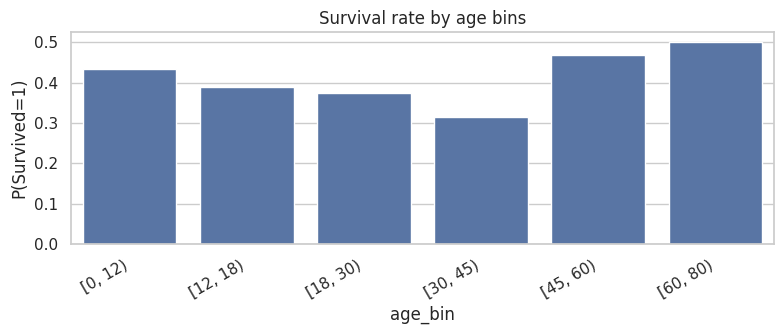

In [ ]:
# Классификация: влияние числовых признаков на Survived
if TARGET_COL is not None:
    key_nums = [c for c in ["Age", "Fare"] if c in df.columns]

    for c in key_nums:
        tmp = df[[c, TARGET_COL]].dropna().copy()
        tmp["_y"] = tmp[TARGET_COL].astype("Int64")

        plt.figure(figsize=(7, 3.5))
        sns.kdeplot(data=tmp, x=c, hue="_y", common_norm=False)
        plt.title(f"{c} distribution by Survived")
        plt.tight_layout()
        plt.show()

    # Age bins (если Age есть)
    if "Age" in df.columns:
        tmp = df[["Age", TARGET_COL]].dropna().copy()
        tmp["age_bin"] = pd.cut(tmp["Age"], bins=[0, 12, 18, 30, 45, 60, 80], right=False)
        tmp["_y"] = tmp[TARGET_COL].astype("Int64")
        rate = tmp.groupby("age_bin")["_y"].agg(["mean", "count"]).rename(columns={"mean": "survival_rate", "count": "n"})
        display(rate)

        plt.figure(figsize=(8, 3.5))
        sns.barplot(x=rate.index.astype(str), y=rate["survival_rate"].values)
        plt.xticks(rotation=30, ha="right")
        plt.ylabel("P(Survived=1)")
        plt.title("Survival rate by age bins")
        plt.tight_layout()
        plt.show()


In [ ]:
# Числовые признаки: describe + выбросы (IQR)
if num_cols:
    display(df[num_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T)

    def iqr_outlier_share(s: pd.Series) -> float:
        s = s.dropna()
        if len(s) < 4:
            return np.nan
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            return 0.0
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        return ((s < lo) | (s > hi)).mean()

    outlier = pd.DataFrame({
        "outlier_share_iqr": [iqr_outlier_share(df[c]) for c in num_cols]
    }, index=num_cols).sort_values("outlier_share_iqr", ascending=False)

    display(outlier)
else:
    print("Нет числовых столбцов")


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Age,332.0,30.272590,14.181209,0.17,0.857900,8.0000,21.0000,27.0000,39.0,57.00,64.000,76.0000
Parch,418.0,0.392344,0.981429,0.00,0.000000,0.0000,0.0000,0.0000,0.0,2.00,4.000,9.0000
Fare,417.0,35.627188,55.907576,0.00,6.446828,7.2292,7.8958,14.4542,31.5,151.55,262.375,512.3292


,outlier_share_iqr
Fare,0.131894
Age,0.006024
Parch,0.000000


In [ ]:
# Категориальные признаки: топ значений

def top_values(s: pd.Series, k: int = 10) -> pd.DataFrame:
    vc = s.astype("string").fillna("<NA>").value_counts(dropna=False).head(k)
    out = vc.to_frame("count")
    out["share"] = out["count"] / len(s)
    return out

if cat_cols:
    for c in cat_cols:
        print(f"\n--- {c} ---")
        display(top_values(df[c], k=15))
else:
    print("Нет категориальных столбцов")



--- Cabin ---


,count,share
Cabin,,
<NA>,327,0.782297
B57 B59 B63 B66,3,0.007177
B45,2,0.004785
C78,2,0.004785
C31,2,0.004785
C23 C25 C27,2,0.004785
C101,2,0.004785
C55 C57,2,0.004785
C116,2,0.004785



--- Embarked ---


,count,share
Embarked,,
S,270,0.645933
C,102,0.244019
Q,46,0.110048



--- Name ---


...

,count,share
SibSp,,
0,283,0.677033
1,110,0.263158
2,14,0.033493
3,4,0.009569
4,4,0.009569
8,2,0.004785
5,1,0.002392



--- Survived ---


,count,share
Survived,,
0,266,0.636364
1,152,0.363636



--- Ticket ---


,count,share
Ticket,,
PC 17608,5,0.011962
113503,4,0.009569
CA. 2343,4,0.009569
C.A. 31029,3,0.007177
PC 17483,3,0.007177
347077,3,0.007177
SOTON/O.Q. 3101315,3,0.007177
16966,3,0.007177
220845,3,0.007177


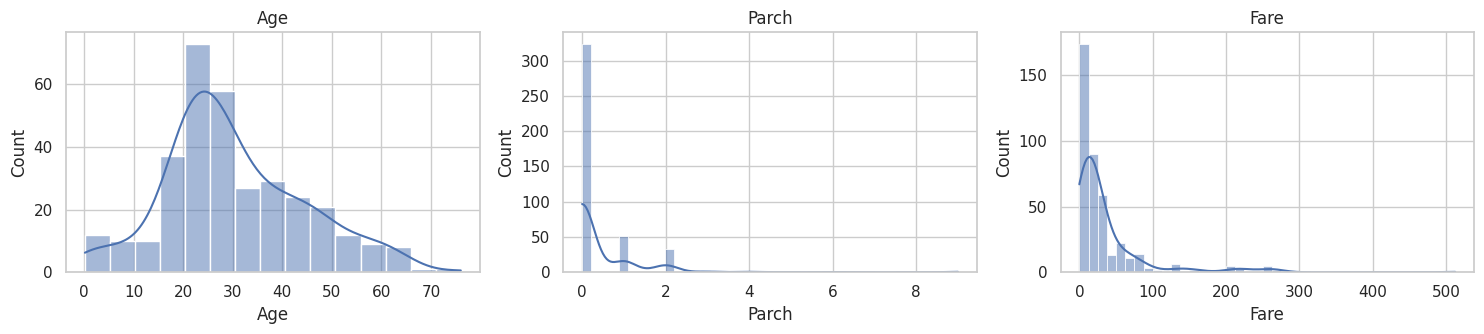

In [ ]:
# Визуализация распределений для числовых
if num_cols:
    n = len(num_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3.5))
    axes = np.array(axes).reshape(-1)

    for ax, c in zip(axes, num_cols):
        sns.histplot(df[c], kde=True, ax=ax)
        ax.set_title(c)

    # выключим лишние оси
    for ax in axes[len(num_cols):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
# Boxplot для числовых (быстро ловит выбросы)
if num_cols:
    n = len(num_cols)
    ncols = 3
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 3.5))
    axes = np.array(axes).reshape(-1)

    for ax, c in zip(axes, num_cols):
        sns.boxplot(x=df[c], ax=ax)
        ax.set_title(c)

    for ax in axes[len(num_cols):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


NameError: name 'num_cols' is not defined

,Age,Parch,Fare
Age,1.000000,-0.061249,0.337932
Parch,-0.061249,1.000000,0.230046
Fare,0.337932,0.230046,1.000000


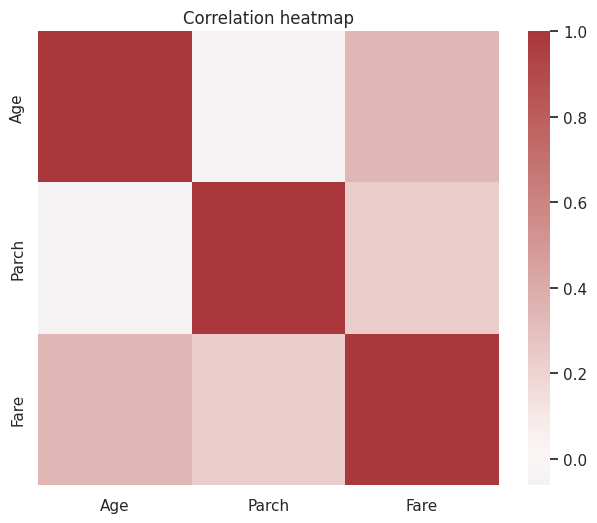

In [ ]:
# Корреляции (только числовые)
if len(num_cols) >= 2:
    corr = df[num_cols].corr(numeric_only=True)
    display(corr)

    plt.figure(figsize=(0.8 * len(num_cols) + 4, 0.8 * len(num_cols) + 3))
    sns.heatmap(corr, annot=False, cmap="vlag", center=0)
    plt.title("Correlation heatmap")
    plt.tight_layout()
    plt.show()


## Выводы по датасету Titanic (Kaggle)

Ниже — типовые выводы, которые обычно подтверждаются на Titanic (и их можно проверить графиками выше на твоём файле):

- **Это задача классификации**: целевая переменная — `Survived` (0/1). Для ориентира полезно сравниваться с baseline «всегда предсказывать самый частый класс».
- **Сильные предикторы**:
  - `Sex`: женщины выживали заметно чаще мужчин.
  - `Pclass`: пассажиры 1-го класса выживали чаще, 3-го — реже.
  - `Fare`: более высокая стоимость билета обычно связана с более высокой вероятностью выживания (частично отражает класс).
- **Возраст**:
  - дети (примерно до 12 лет) часто имеют более высокий survival rate;
  - распределения по `Age` между выжившими/невыжившими обычно различаются, но эффект слабее, чем у `Sex` и `Pclass`.
- **Пропуски важны**:
  - `Cabin` часто почти пустой;
  - `Age` часто содержит пропуски и обычно требует импутации.
- **Про категориальные числа**:
  - `PassengerId` — идентификатор (как правило, **не использовать как фичу**);
  - `Pclass`, `SibSp` (и часто `Parch`) — категории/счётчики, их полезно смотреть как категории (value_counts + survival rate по группам).

Если хочешь — добавлю в ноутбук блок «подготовка к модели» (one-hot для категорий, импутация, простая логистическая регрессия/дерево) и быстрый cross-val, чтобы подтвердить выводы метриками.
